# Lab 06: Unsupervised Learning – Identifying Structural Patterns and Development Paths

## Necessary imports

In [35]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from factor_analyzer.factor_analyzer import calculate_kmo, calculate_bartlett_sphericity
from sklearn.preprocessing import StandardScaler
from factor_analyzer import FactorAnalyzer
from mpl_toolkits.mplot3d import Axes3D
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

## Task 1: Data exploration and preparation

In [2]:
# 1. Load the dataset from the provided link
url = "https://github.com/masterfloss/data/raw/refs/heads/main/WBESG6123.xlsx"
print("Loading dataset...")
df = pd.read_excel(url, index_col=0)

Loading dataset...


In [3]:
# 2. Inspect its structure and variables
print("\n--- Initial Long Format Structure ---")
print(df.info())
print("\n--- First 5 Rows ---")
df.head()


--- Initial Long Format Structure ---
<class 'pandas.core.frame.DataFrame'>
Index: 461719 entries, 0 to 461718
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   INDICATOR_LABEL  461719 non-null  object 
 1   FREQ_LABEL       461719 non-null  object 
 2   TIME_PERIOD      461719 non-null  int64  
 3   REF_AREA_LABEL   461719 non-null  object 
 4   OBS_VALUE        461719 non-null  float64
 5   UNIT_TYPE_LABEL  461719 non-null  object 
dtypes: float64(1), int64(1), object(4)
memory usage: 24.7+ MB
None

--- First 5 Rows ---


,INDICATOR_LABEL,FREQ_LABEL,TIME_PERIOD,REF_AREA_LABEL,OBS_VALUE,UNIT_TYPE_LABEL
0,Agricultural land (% of land area),Annual,1961,Afghanistan,57.878356,Ratio
1,Agricultural land (% of land area),Annual,1961,Angola,36.237266,Ratio
2,Agricultural land (% of land area),Annual,1961,Albania,44.963504,Ratio
3,Agricultural land (% of land area),Annual,1961,Andorra,55.319149,Ratio
4,Agricultural land (% of land area),Annual,1961,Arab World,27.845967,Ratio


In [4]:
# 3. Transform the dataset from long format into wide format
# Each observation corresponds to a country-year combination
# Each column corresponds to an indicator
df_wide = df.pivot_table(
    index=['REF_AREA_LABEL', 'TIME_PERIOD'],
    columns='INDICATOR_LABEL',
    values='OBS_VALUE'
).reset_index()

print("\n--- Wide Format Structure ---")
print(df_wide.info())


--- Wide Format Structure ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15296 entries, 0 to 15295
Data columns (total 73 columns):
 #   Column                                                                                                     Non-Null Count  Dtype  
---  ------                                                                                                     --------------  -----  
 0   REF_AREA_LABEL                                                                                             15296 non-null  object 
 1   TIME_PERIOD                                                                                                15296 non-null  int64  
 2   Access to clean fuels and technologies for cooking (% of population)                                       5405 non-null   float64
 3   Access to electricity (% of population)                                                                    7053 non-null   float64
 4   Adjusted savings: natural resources dep

In [6]:
# 4. Check for missing values
print("\n--- Missing Values Count and Percentage per Indicator ---")

# Calculate absolute counts and percentages
missing_counts = df_wide.isnull().sum()
missing_percentages = (df_wide.isnull().mean() * 100).round(2)

# Combine into a single DataFrame for clean viewing
missing_summary = pd.DataFrame({
    'Missing Count': missing_counts,
    'Missing Percentage (%)': missing_percentages
})

# Display the summary
missing_summary


--- Missing Values Count and Percentage per Indicator ---


,Missing Count,Missing Percentage (%)
INDICATOR_LABEL,,
REF_AREA_LABEL,0,0.00
TIME_PERIOD,0,0.00
Access to clean fuels and technologies for cooking (% of population),9891,64.66
Access to electricity (% of population),8243,53.89
Adjusted savings: natural resources depletion (% of GNI),5835,38.15
...,...,...
Terrestrial and marine protected areas (% of total territorial area),12692,82.98
Tree Cover Loss (hectares),11536,75.42
"Unemployment, total (% of total labor force) (modeled ILO estimate)",7907,51.69


In [7]:
# 5. Examine descriptive statistics for the resulting variables
print("\n--- Descriptive Statistics ---")
df_wide.describe()


--- Descriptive Statistics ---


INDICATOR_LABEL,TIME_PERIOD,Access to clean fuels and technologies for cooking (% of population),Access to electricity (% of population),Adjusted savings: natural resources depletion (% of GNI),Adjusted savings: net forest depletion (% of GNI),Agricultural land (% of land area),"Agriculture, forestry, and fishing, value added (% of GDP)","Annual freshwater withdrawals, total (% of internal resources)","Annualized average growth rate in per capita real survey mean consumption or income, total population (%)",CO2 emissions (metric tons per capita),...,"School enrollment, primary (% gross)","School enrollment, primary and secondary (gross), gender parity index (GPI)",Scientific and technical journal articles,Standardised Precipitation-Evapotranspiration Index,Strength of legal rights index (0=weak to 12=strong),Terrestrial and marine protected areas (% of total territorial area),Tree Cover Loss (hectares),"Unemployment, total (% of total labor force) (modeled ILO estimate)",Unmet need for contraception (% of married women ages 15-49),Voice and Accountability: Estimate
count,15296.000000,5405.000000,7053.000000,9461.000000,9860.000000,13677.000000,10504.000000,6301.000000,116.000000,7346.000000,...,10532.000000,7907.000000,6.453000e+03,11655.000000,1617.000000,2604.000000,3.760000e+03,7389.000000,699.000000,4812.000000
mean,1991.500000,62.608166,79.601199,4.556609,1.547121,37.487024,15.735637,130.978535,1.491724,4.164599,...,96.956429,0.920101,6.373458e+04,-0.081237,5.103747,12.236180,1.124245e+05,7.788359,19.725341,-0.045087
std,18.473557,37.923883,29.034461,7.499877,3.977357,20.249277,13.406535,673.110784,2.847319,5.214568,...,19.805614,0.146681,2.349173e+05,1.069604,2.794492,12.308024,4.515032e+05,5.572187,8.964358,1.004727
min,1960.000000,0.000000,0.533899,0.000000,0.000000,0.255440,0.000000,0.013759,-6.110000,0.000000,...,3.081780,0.000000,0.000000e+00,-4.488547,0.000000,0.000000,0.000000e+00,0.100000,1.700000,-2.313395
25%,1975.750000,23.470919,64.820190,0.232344,0.000000,21.659534,4.790123,2.120223,-0.185000,0.690957,...,92.743746,0.858715,3.536000e+01,-0.866372,3.000000,3.400000,6.075000e+01,4.045000,12.500000,-0.882851
50%,1991.500000,77.100000,97.054290,1.564074,0.042309,37.454343,12.204192,9.662282,1.295000,2.393457,...,100.712540,0.981730,4.717700e+02,-0.107569,5.000000,9.484410,4.181000e+03,6.287695,19.400000,-0.004253
75%,2007.250000,100.000000,100.000000,5.723662,0.767642,51.020450,23.836222,34.161905,3.167500,6.052474,...,106.420876,1.009055,1.139071e+04,0.672719,7.000000,17.300000,4.613275e+04,9.959000,26.183403,0.859783
max,2023.000000,100.000000,100.000000,102.890683,44.864240,93.440750,89.414510,7750.000000,9.800000,47.941117,...,216.768875,1.449290,3.338192e+06,4.119098,12.000000,100.000000,6.518852e+06,38.800000,55.900000,1.800992



--- Indicator Index Mapping ---
[0] TIME_PERIOD
[1] Access to clean fuels and technologies for cooking (% of population)
[2] Access to electricity (% of population)
[3] Adjusted savings: natural resources depletion (% of GNI)
[4] Adjusted savings: net forest depletion (% of GNI)
[5] Agricultural land (% of land area)
[6] Agriculture, forestry, and fishing, value added (% of GDP)
[7] Annual freshwater withdrawals, total (% of internal resources)
[8] Annualized average growth rate in per capita real survey mean consumption or income, total population (%)
[9] CO2 emissions (metric tons per capita)
[10] Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)
[11] Children in employment, total (% of children ages 7-14)
[12] Coastal protection
[13] Control of Corruption: Estimate
[14] Cooling Degree Days
[15] Economic and Social Rights Performance Score
[16] Electricity production from coal sources (% of total)
[17] Energy imports, net (% of ene

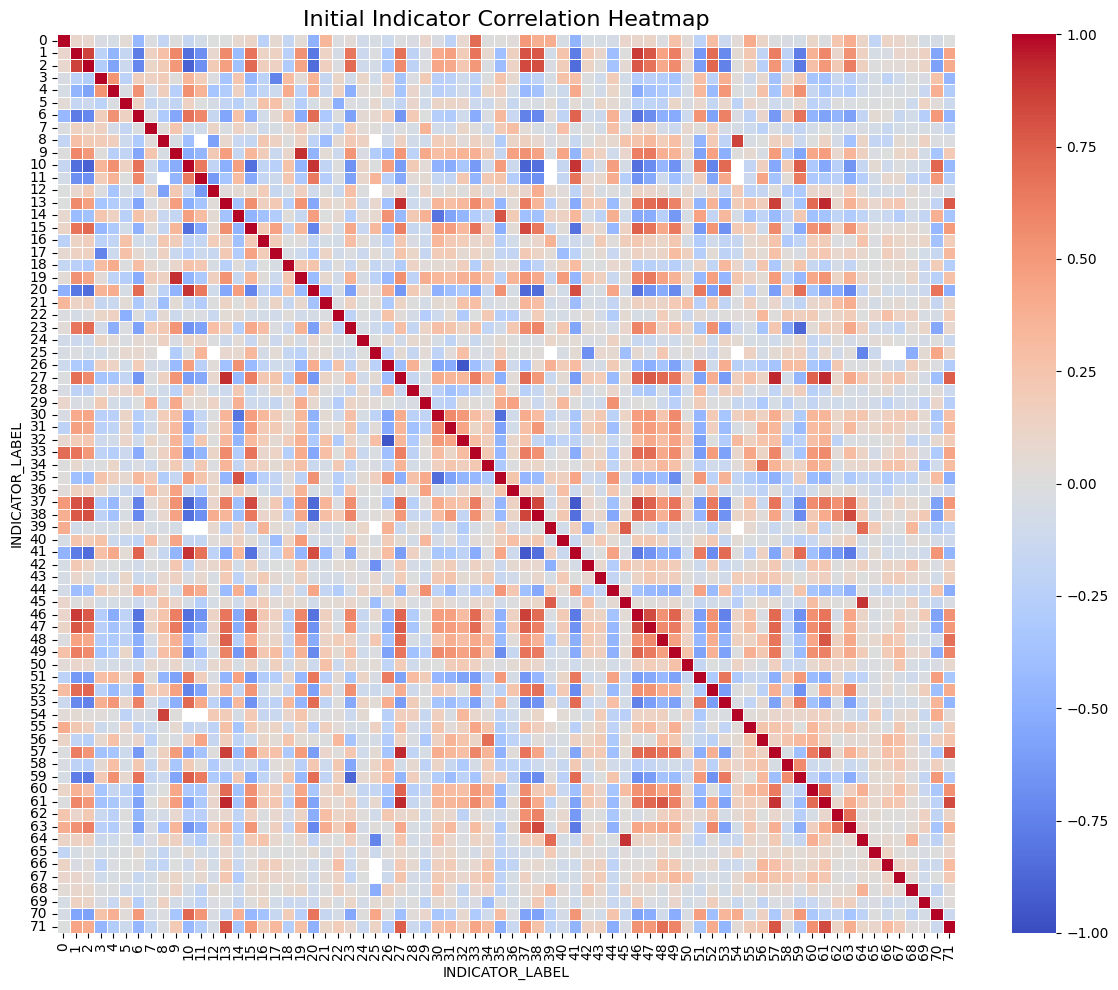


--- Highly Correlated Variables (|r| >= 0.75) ---
-0.958 : Gini index  <-->  Income share held by lowest 20%
-0.939 : Life expectancy at birth, total (years)  <-->  Mortality rate, under-5 (per 1,000 live births)
+0.937 : Control of Corruption: Estimate  <-->  Rule of Law: Estimate
+0.936 : Government Effectiveness: Estimate  <-->  Rule of Law: Estimate
+0.931 : Government Effectiveness: Estimate  <-->  Regulatory Quality: Estimate
+0.921 : Control of Corruption: Estimate  <-->  Government Effectiveness: Estimate
+0.907 : CO2 emissions (metric tons per capita)  <-->  Energy use (kg of oil equivalent per capita)
+0.905 : Regulatory Quality: Estimate  <-->  Rule of Law: Estimate
+0.904 : Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)  <-->  Mortality rate, under-5 (per 1,000 live births)
+0.904 : Cause of death, by communicable diseases and maternal, prenatal and nutrition conditions (% of total)  <-->  Fertility rate, total (births

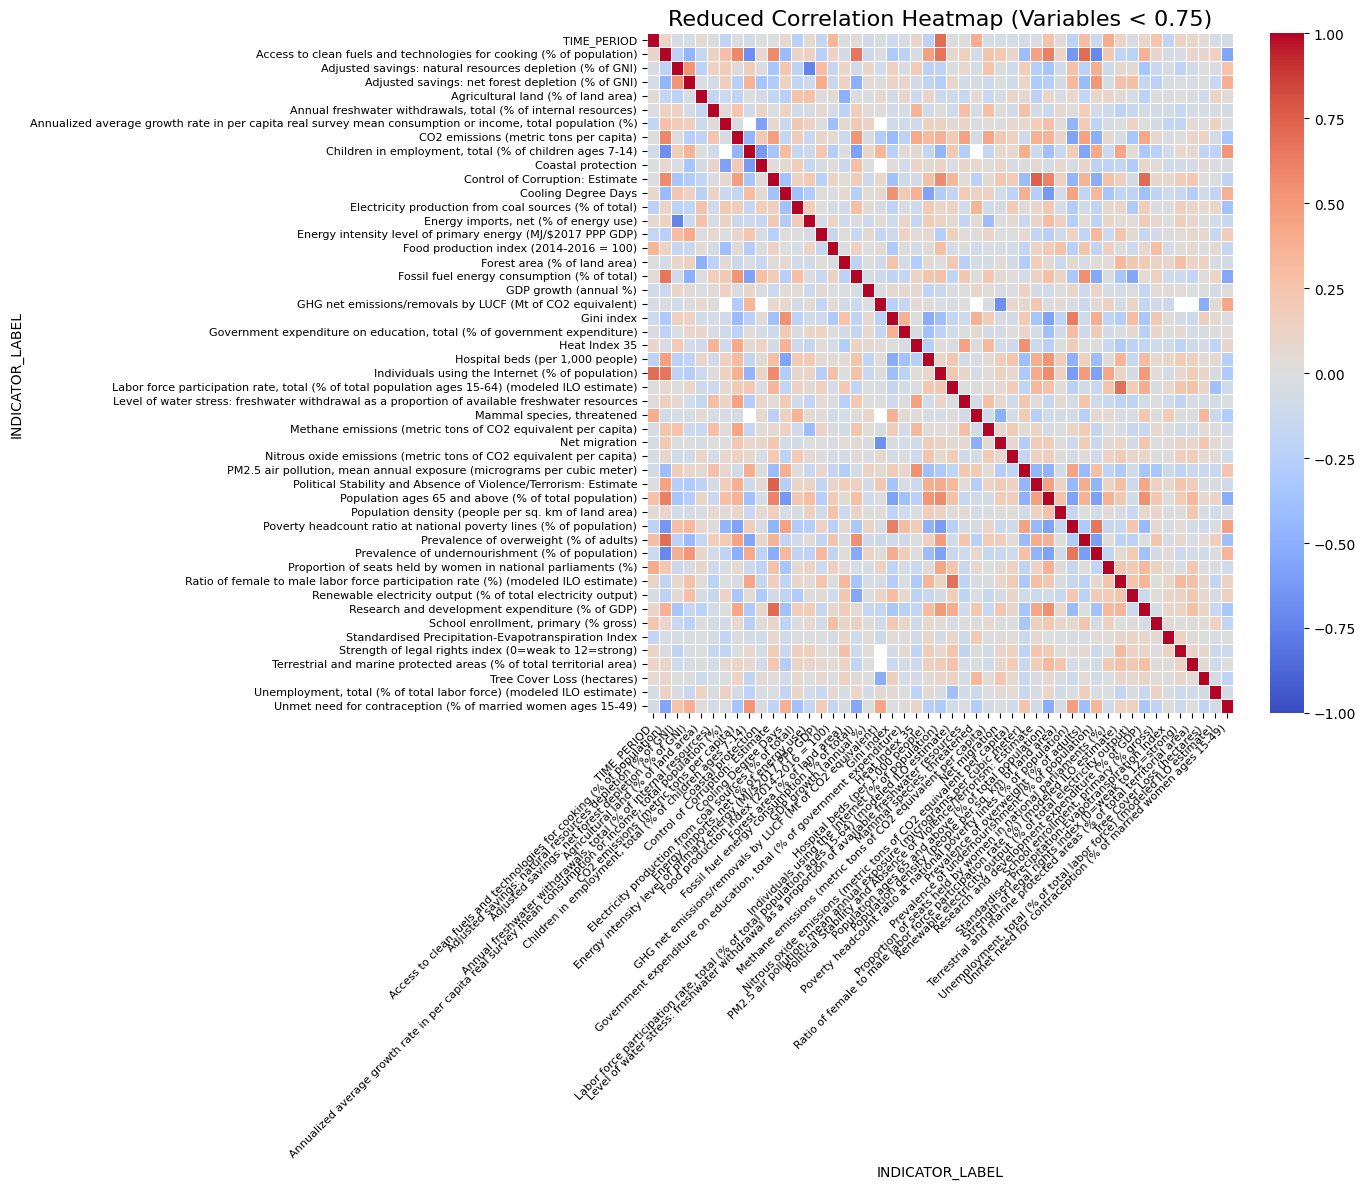

In [8]:
# 6. Analyze correlations between indicators

# --- 1. Initial Correlation Matrix and Numbered Heatmap ---
correlation_matrix = df_wide.corr(numeric_only=True)

indicator_names = correlation_matrix.columns.tolist()
print("\n--- Indicator Index Mapping ---")
for idx, name in enumerate(indicator_names):
    print(f"[{idx}] {name}")

plt.figure(figsize=(12, 10))
plt.title("Initial Indicator Correlation Heatmap", fontsize=16)
sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    xticklabels=range(len(indicator_names)),
    yticklabels=range(len(indicator_names))
)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- 2. Highlight Highly Correlated Variables ---
threshold = 0.75

# Find pairs above the threshold
corr_pairs = correlation_matrix.unstack()
corr_pairs = corr_pairs[corr_pairs.index.get_level_values(0) != corr_pairs.index.get_level_values(1)]
high_corr = corr_pairs[abs(corr_pairs) >= threshold]
high_corr = high_corr.loc[~high_corr.index.map(frozenset).duplicated()]
high_corr = high_corr.sort_values(key=abs, ascending=False)

print(f"\n--- Highly Correlated Variables (|r| >= {threshold}) ---")
if not high_corr.empty:
    for (var1, var2), corr_val in high_corr.items():
        print(f"{corr_val:+.3f} : {var1}  <-->  {var2}")
else:
    print("No variable pairs met the correlation threshold.")


# --- 3. Drop Highly Correlated Variables ---
# We iterate through the upper triangle of the correlation matrix
# to flag one variable from each highly correlated pair for removal.
cols_to_drop = set()
for i in range(len(correlation_matrix.columns)):
    for j in range(i):
        if abs(correlation_matrix.iloc[i, j]) >= threshold:
            colname = correlation_matrix.columns[i]
            cols_to_drop.add(colname)

print(f"\nDropping {len(cols_to_drop)} variables due to high correlation...")
df_reduced = df_wide.drop(columns=cols_to_drop)


# --- 4. Plot Reduced Heatmap with Variable Names ---
reduced_correlation = df_reduced.corr(numeric_only=True)

plt.figure(figsize=(14, 12))
plt.title("Reduced Correlation Heatmap (Variables < 0.75)", fontsize=16)
sns.heatmap(
    reduced_correlation,
    annot=False,
    cmap='coolwarm',
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    xticklabels=reduced_correlation.columns, # Use actual names this time
    yticklabels=reduced_correlation.columns
)
plt.xticks(rotation=45, ha='right', fontsize=8) # Rotate for better fit
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

# Save the final indicator columns for the next steps
final_indicators = df_reduced.columns.drop(['REF_AREA_LABEL', 'TIME_PERIOD'], errors='ignore')

## Task 1_2: Data cleaning and processing



*   Check and drop countries with less than 50% data filled
*   Check and keep years within the top 5% fill-in rates



In [9]:
# Use the list of final indicators from the correlation step
indicator_cols = final_indicators

# --- STEP 1: Check and drop countries with < 50% data filled ---

# Calculate total valid data points vs total possible data points per country using df_reduced
country_valid = df_reduced.groupby('REF_AREA_LABEL')[indicator_cols].count().sum(axis=1)
country_total = df_reduced.groupby('REF_AREA_LABEL')[indicator_cols].size() * len(indicator_cols)
country_fill_rates = (country_valid / country_total) * 100

# Keep only countries with >= 50% fill rate
valid_countries = country_fill_rates[country_fill_rates >= 50.0].index
df_filtered = df_reduced[df_reduced['REF_AREA_LABEL'].isin(valid_countries)].copy()

print(f"Kept {len(valid_countries)} countries out of {len(country_fill_rates)}.")


# --- STEP 2: Check fill-in rates by year (on the remaining countries) ---

# Calculate total valid data points vs total possible data points per year using df_filtered
year_valid = df_filtered.groupby('TIME_PERIOD')[indicator_cols].count().sum(axis=1)
year_total = df_filtered.groupby('TIME_PERIOD')[indicator_cols].size() * len(indicator_cols)
year_fill_rates = (year_valid / year_total) * 100

print("\n--- Fill Rates by Year (%) ---")
print(year_fill_rates.sort_values(ascending=False))


# --- STEP 3: Keep only the years with the highest fill-in rates ---

# Let's define "highest" as any year that is within 5% of the absolute best year's fill rate.
max_fill_rate = year_fill_rates.max()
threshold = max_fill_rate - 5

valid_years = year_fill_rates[year_fill_rates >= threshold].index
df_final = df_filtered[df_filtered['TIME_PERIOD'].isin(valid_years)].copy()

print(f"\nKept {len(valid_years)} years with a fill rate >= {threshold:.2f}%: \n{valid_years.tolist()}")

Kept 22 countries out of 239.

--- Fill Rates by Year (%) ---
TIME_PERIOD
2018    90.246212
2016    88.068182
2019    87.973485
2017    87.878788
2013    87.689394
          ...    
1963    14.772727
1964    14.772727
1961    14.678030
1962    14.678030
1960     7.291667
Length: 64, dtype: float64

Kept 8 years with a fill rate >= 85.25%: 
[2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020]




*   Fill in missing data
*   Dropping stubborn indicators



In [12]:
# 1. Sort by country and year to ensure strict chronological order using our filtered dataset
df_final = df_final.sort_values(by=['REF_AREA_LABEL', 'TIME_PERIOD'])

# 2. Isolate the indicator columns (using the final_indicators list from our correlation step)
indicator_cols = final_indicators

# 3. Group by country and apply the imputation logic strictly within each group
# - interpolate(method='linear'): Calculates the midpoint for gaps between two known years
# - ffill(): Carries the last known value forward if there are no future values
# - bfill(): Carries the first known value backward if the earliest years are missing
df_final[indicator_cols] = df_final.groupby('REF_AREA_LABEL')[indicator_cols].transform(
    lambda x: x.interpolate(method='linear').ffill().bfill()
)

# 4. Check for any remaining missing values
remaining_missing = df_final[indicator_cols].isnull().sum()
stubborn_cols = remaining_missing[remaining_missing > 0].index

# 5. Automatically drop columns that still have missing data
print(f"\n--- Dropping {len(stubborn_cols)} columns that still contain missing values ---")

if len(stubborn_cols) > 0:
    for col in stubborn_cols:
        print(f"Dropping: {col}")

    # Drop the stubborn columns from the dataframe
    df_final = df_final.drop(columns=stubborn_cols)

    # Update our list of indicator columns so we don't try to use them in Factor Analysis
    indicator_cols = indicator_cols.drop(stubborn_cols)
    final_indicators = indicator_cols # Keep our master list updated

# 6. Final Verification
print(f"\nFinal clean dataset shape: {df_final.shape}")
print(f"Total missing values in final dataset: {df_final.isnull().sum().sum()} (Should be 0)")


--- Dropping 0 columns that still contain missing values ---

Final clean dataset shape: (176, 44)
Total missing values in final dataset: 0 (Should be 0)


### Final check before Factor Analysis


*   **Variables standardization** to z-score due to high dispersion in measurement scale
*   **Kaiser-Meyer-Olkin (KMO) Test**: Whether sample size is adequate for the variables we have (>0.6 needed)
*   **Barlett's Test of Sphericity**: Confirms high enough correlation between varaibels to form latent factors



In [16]:
# 1. Isolate the data
data_for_fa = df_final[indicator_cols]

# 2. Standardize the variables
scaler = StandardScaler()
data_scaled = scaler.fit_transform(data_for_fa)
df_scaled = pd.DataFrame(data_scaled, columns=indicator_cols, index=df_final.index)

# 3. Bartlett's Test of Sphericity
# Tests if the variables are correlated enough to form underlying factors
chi_square_value, p_value = calculate_bartlett_sphericity(df_scaled)

print("--- Bartlett's Test of Sphericity ---")
print(f"Chi-Square: {chi_square_value:.2f}")
print(f"P-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: Pass! The p-value is < 0.05. Variables are correlated enough for Factor Analysis.")
else:
    print("Result: Fail. Variables may not be correlated enough.")

# 4. Kaiser-Meyer-Olkin (KMO) Test
# Measures if your sample size is adequate for the specific variables you have
# Note: KMO can sometimes throw a warning or error if a variable has zero variance
# or perfect collinearity. We already handled collinearity, so it should run smoothly!
kmo_all, kmo_model = calculate_kmo(df_scaled)

print("\n--- Kaiser-Meyer-Olkin (KMO) Test ---")
print(f"Overall KMO Score: {kmo_model:.3f}")
if kmo_model >= 0.60:
    print("Result: Pass! The KMO score is >= 0.60, indicating adequate sample size/correlations.")
else:
    print("Result: Suboptimal. A KMO score < 0.60 suggests the data might be thin for this many variables.")

--- Bartlett's Test of Sphericity ---
Chi-Square: 12325.06
P-value: 0.0000
Result: Pass! The p-value is < 0.05. Variables are correlated enough for Factor Analysis.

--- Kaiser-Meyer-Olkin (KMO) Test ---
Overall KMO Score: 0.649
Result: Pass! The KMO score is >= 0.60, indicating adequate sample size/correlations.


/usr/local/lib/python3.12/dist-packages/factor_analyzer/utils.py:244: UserWarning: The inverse of the variance-covariance matrix was calculated using the Moore-Penrose generalized matrix inversion, due to its determinant being at or very close to zero.
  warnings.warn(


## Task 2: Factor Analysis

In [17]:
# --- 1. Select Indicators and Standardize Variables ---
# We select the indicators to include in the analysis.
X = df_final[indicator_cols]

# We standardize the variables if necessary, which we established is required.
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns, index=X.index)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


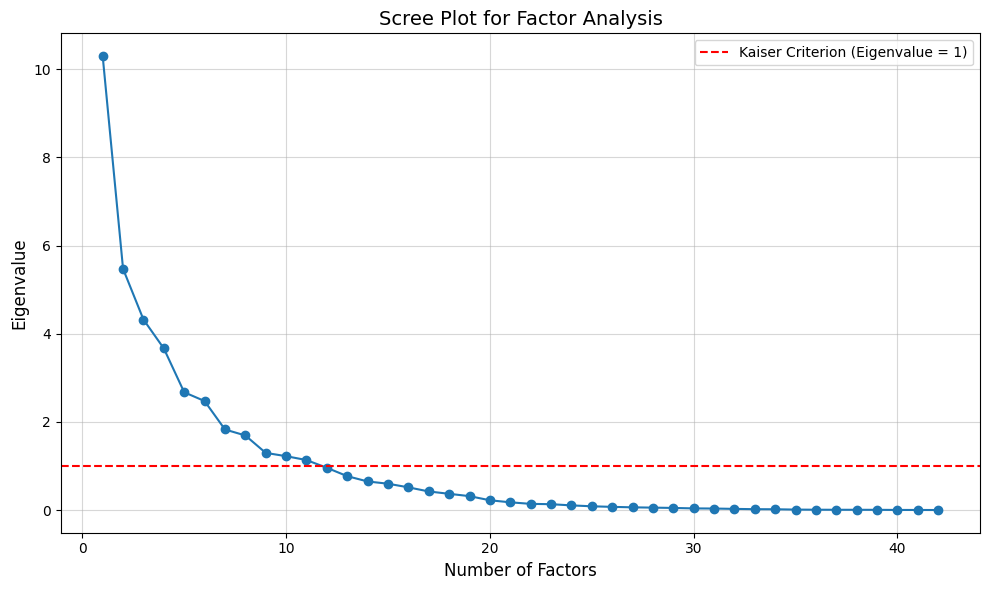

Number of factors with an eigenvalue > 1 (Kaiser Criterion): 11


In [20]:
# --- 2. Determine an Appropriate Number of Factors ---
# Determine an appropriate number of factors using common criteria (for example eigenvalues or scree plots).
# Initialize a base FactorAnalyzer to calculate eigenvalues for all possible factors
fa_temp = FactorAnalyzer(n_factors=X_scaled.shape[1], rotation=None)
fa_temp.fit(X_scaled)

# Extract eigenvalues
ev, v = fa_temp.get_eigenvalues()

# Create the Scree Plot
plt.figure(figsize=(10, 6))
plt.plot(range(1, X_scaled.shape[1] + 1), ev, marker='o', linestyle='-')
plt.title('Scree Plot for Factor Analysis', fontsize=14)
plt.xlabel('Number of Factors', fontsize=12)
plt.ylabel('Eigenvalue', fontsize=12)
plt.axhline(y=1, color='r', linestyle='--', label='Kaiser Criterion (Eigenvalue = 1)')
plt.legend()
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

# Calculate how many factors meet the Kaiser Criterion
num_factors_kaiser = sum(ev > 1)
print(f"Number of factors with an eigenvalue > 1 (Kaiser Criterion): {num_factors_kaiser}")

*   Number of variables based on **Kaiser**: 11
*   Number of variables based on **Scree Plot**: 5

Proceeding first with Kaiser selection.

In [21]:
# --- 3. Estimate the Factor Model ---
# Use the Kaiser criterion output as a starting point.
n_factors = num_factors_kaiser
print(f"\nEstimating the factor model using {n_factors} factors and 'varimax' rotation...")

fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(X_scaled)


Estimating the factor model using 11 factors and 'varimax' rotation...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


FactorAnalyzer(n_factors=np.int64(11), rotation='varimax', rotation_kwargs={})

In [22]:
# --- 4. Examine the Factor Loadings ---
# We examine the factor loadings.
loadings = pd.DataFrame(
    fa.loadings_,
    index=X_scaled.columns,
    columns=[f'Factor {i+1}' for i in range(n_factors)]
)

# We interpret the factors by identifying which variables load strongly on each factor.
print("\n--- Top Variables Loading Strongly on Each Factor ---")
for col in loadings.columns:
    # Sort by absolute value to find the strongest relationships (both positive and negative)
    top_vars = loadings[col].abs().sort_values(ascending=False).head(5)
    print(f"\n{col}:")
    for var, abs_val in top_vars.items():
        # Print the actual loading value (preserving the +/- sign)
        actual_val = loadings.loc[var, col]
        print(f"  {actual_val:+.3f} : {var}")


--- Top Variables Loading Strongly on Each Factor ---

Factor 1:
  +0.896 : Control of Corruption: Estimate
  +0.878 : Labor force participation rate, total (% of total population ages 15-64) (modeled ILO estimate)
  +0.871 : Ratio of female to male labor force participation rate (%) (modeled ILO estimate)
  -0.868 : Gini index
  +0.779 : Individuals using the Internet (% of population)

Factor 2:
  +0.833 : Annual freshwater withdrawals, total (% of internal resources)
  +0.818 : Level of water stress: freshwater withdrawal as a proportion of available freshwater resources
  +0.573 : Cooling Degree Days
  +0.566 : Research and development expenditure (% of GDP)
  +0.542 : Population density (people per sq. km of land area)

Factor 3:
  -0.869 : Access to clean fuels and technologies for cooking (% of population)
  +0.747 : PM2.5 air pollution, mean annual exposure (micrograms per cubic meter)
  +0.553 : Mammal species, threatened
  -0.552 : Prevalence of overweight (% of adults)
  +0

Significant drop in loading factor from factor 5 to factor 6. Should drop the number of factors to 5 based on Scree Plot.

In [24]:
# --- 5. Re-estimating the Factor Model ---
# Using Scree Plot result
n_factors = 5
print(f"\nEstimating the factor model using {n_factors} factors and 'varimax' rotation...")

fa = FactorAnalyzer(n_factors=n_factors, rotation='varimax')
fa.fit(X_scaled)

# Examine the factor loadings.
loadings = pd.DataFrame(
    fa.loadings_,
    index=X_scaled.columns,
    columns=[f'Factor {i+1}' for i in range(n_factors)]
)

# Interpret the factors by identifying which variables load strongly on each factor.
print("\n--- Top Variables Loading Strongly on Each Factor ---")
for col in loadings.columns:
    # Sort by absolute value to find the strongest relationships (both positive and negative)
    top_vars = loadings[col].abs().sort_values(ascending=False).head(5)
    print(f"\n{col}:")
    for var, abs_val in top_vars.items():
        # Print the actual loading value (preserving the +/- sign)
        actual_val = loadings.loc[var, col]
        print(f"  {actual_val:+.3f} : {var}")


Estimating the factor model using 5 factors and 'varimax' rotation...

--- Top Variables Loading Strongly on Each Factor ---

Factor 1:
  +0.883 : Gini index
  -0.819 : Population ages 65 and above (% of total population)
  +0.791 : Cooling Degree Days
  +0.789 : Mammal species, threatened
  +0.773 : Prevalence of undernourishment (% of population)

Factor 2:
  +0.798 : Population density (people per sq. km of land area)
  +0.794 : Annual freshwater withdrawals, total (% of internal resources)
  +0.772 : Level of water stress: freshwater withdrawal as a proportion of available freshwater resources
  -0.624 : Renewable electricity output (% of total electricity output)
  -0.613 : Nitrous oxide emissions (metric tons of CO2 equivalent per capita)

Factor 3:
  +0.828 : CO2 emissions (metric tons per capita)
  +0.748 : Tree Cover Loss (hectares)
  +0.629 : Strength of legal rights index (0=weak to 12=strong)
  +0.495 : Government expenditure on education, total (% of government expenditur

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


**Factor 1: Socioeconomic Vulnerability & Climate**

* High Inequality (Gini)
* High Undernourishment
* Warm Climates (Cooling Degree Days)
* Low Elderly Population

This represents developing, often tropical nations facing structural poverty and demographic youth bulges.

**Factor 2: Water & Resource Stress**

* High Population Density
* Severe Water Stress
* High Freshwater Withdrawals

This clearly isolates countries dealing with severe hydrological and geographical constraints.

**Factor 3: Industrial Carbon Footprint**

* High CO2 Emissions
* Massive Tree Cover Loss
* Higher Legal Rights and Education

This likely points to large, rapidly industrializing or established economies that have massive environmental footprints.

**Factor 4: Clean Infrastructure & Digital Development**

* High Access to Clean Fuels
* High Internet Use
* Low Air Pollution
* Low Coal Reliance

This dimension tracks modernized, clean infrastructure and digital connectivity.

**Factor 5: Conservation & Progressive Governance**

* High Women in Parliament
* High Forest Area
* Low Agricultural Emissions (Methane/Nitrous Oxide)

This represents strong environmental conservation and inclusive political structures.

## Task 3: Factor Scores

In [28]:
# --- 1. Compute Factor Scores ---
# The transform method calculates the score for each country-year observation based on our 5 factors
factor_scores = fa.transform(X_scaled)

# Give our factors the descriptive names we just identified
factor_names = [
    'F1: Socioeconomic Vulnerability',
    'F2: Water & Resource Stress',
    'F3: Industrial Carbon Footprint',
    'F4: Clean Infrastructure & Digital',
    'F5: Conservation & Progressive Gov'
]

# Create a DataFrame for the new scores
df_scores = pd.DataFrame(factor_scores, columns=factor_names, index=X_scaled.index)

# Add the country and year identifiers back so we know who is who!
df_scores['REF_AREA_LABEL'] = df_final['REF_AREA_LABEL']
df_scores['TIME_PERIOD'] = df_final['TIME_PERIOD']

print("--- Factor Scores Successfully Computed ---")
print(df_scores.head())

--- Factor Scores Successfully Computed ---
     F1: Socioeconomic Vulnerability  F2: Water & Resource Stress  \
501                         1.346676                    -0.343948   
502                         1.523392                    -0.986291   
503                         1.752719                    -1.057022   
504                         1.613839                    -1.113226   
505                         1.533391                    -0.404850   

     F3: Industrial Carbon Footprint  F4: Clean Infrastructure & Digital  \
501                        -1.198204                            0.768218   
502                        -0.746399                            0.611346   
503                        -0.229869                            0.201252   
504                        -0.326450                            0.330072   
505                        -0.880447                            0.711500   

     F5: Conservation & Progressive Gov REF_AREA_LABEL  TIME_PERIOD  
501           

/usr/local/lib/python3.12/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


### **What Factor Score reveal about country profiles**

* **Multi-Dimensional Development:** The scores show that country development is not a single straight line from "poor" to "rich." Instead, it is highly nuanced. For example, a country might score very high on Factor 4 (Clean Infrastructure & Digital) but simultaneously score very poorly on Factor 3 (Industrial Carbon Footprint). The scores reveal that economic modernization often comes at the cost of high environmental degradation.
* **Geographic vs. Structural Similarities:** Factor scores can reveal that countries on opposite sides of the planet might share incredibly similar structural challenges. Two countries might have identical positive scores for Factor 2 (Water & Resource Stress), meaning they face the exact same hydrological constraints, regardless of their cultural or economic differences.
* **Isolating Specific Vulnerabilities:** Looking at the snippet you shared for Argentina, we can see it scores positively (above 0) on Factor 1 (Socioeconomic Vulnerability), indicating structural inequality and demographic challenges. However, it scores negatively (below 0) on Factor 2 (Water & Resource Stress). This tells us exactly where Argentina's structural weaknesses lie and where its strengths are. A Middle Eastern nation, by contrast, might show the exact opposite profile.
* **Tracking Policy Impacts (Over Time):** Even within the few years of Argentina data you shared, you can see Factor 5 (Conservation & Progressive Gov) moving from slightly negative (-0.167 in 2014) to strongly positive (+0.788 in 2017). The factor scores reveal the mathematical footprint of structural or policy shifts happening within the country over time.

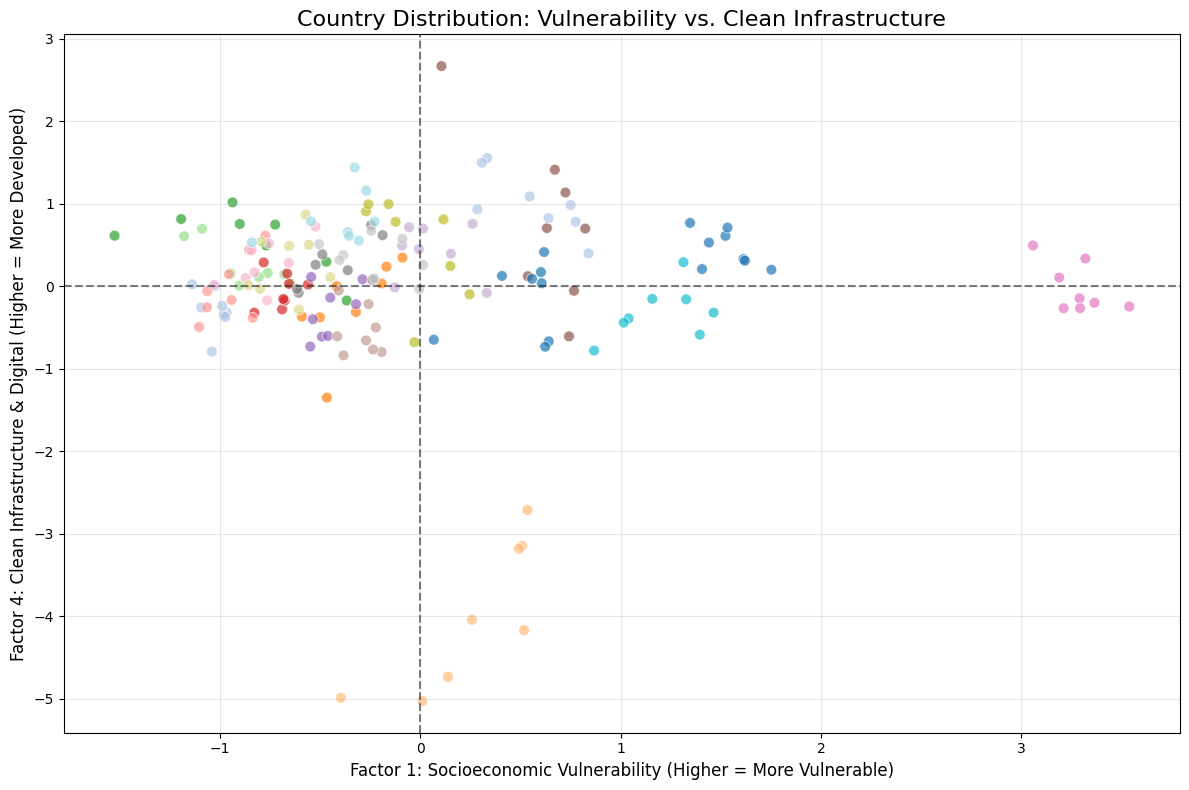

In [27]:
# --- 2. Visualize the Observations in Factor Space ---
# We will plot Factor 1 (Vulnerability) vs Factor 4 (Clean Infrastructure)
# to see the starkest contrasts between structural profiles.

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_scores,
    x='F1: Socioeconomic Vulnerability',
    y='F4: Clean Infrastructure & Digital',
    hue='REF_AREA_LABEL',
    palette='tab20', # Color by country
    legend=False,    # We hide the legend because 100+ countries will crowd the graph
    alpha=0.7,
    s=60
)

# Add quadrant lines at 0 (the average, since our data was standardized)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)

plt.title('Country Distribution: Vulnerability vs. Clean Infrastructure', fontsize=16)
plt.xlabel('Factor 1: Socioeconomic Vulnerability (Higher = More Vulnerable)', fontsize=12)
plt.ylabel('Factor 4: Clean Infrastructure & Digital (Higher = More Developed)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Generating Pairplot... This will show all 5 dimensions against each other.


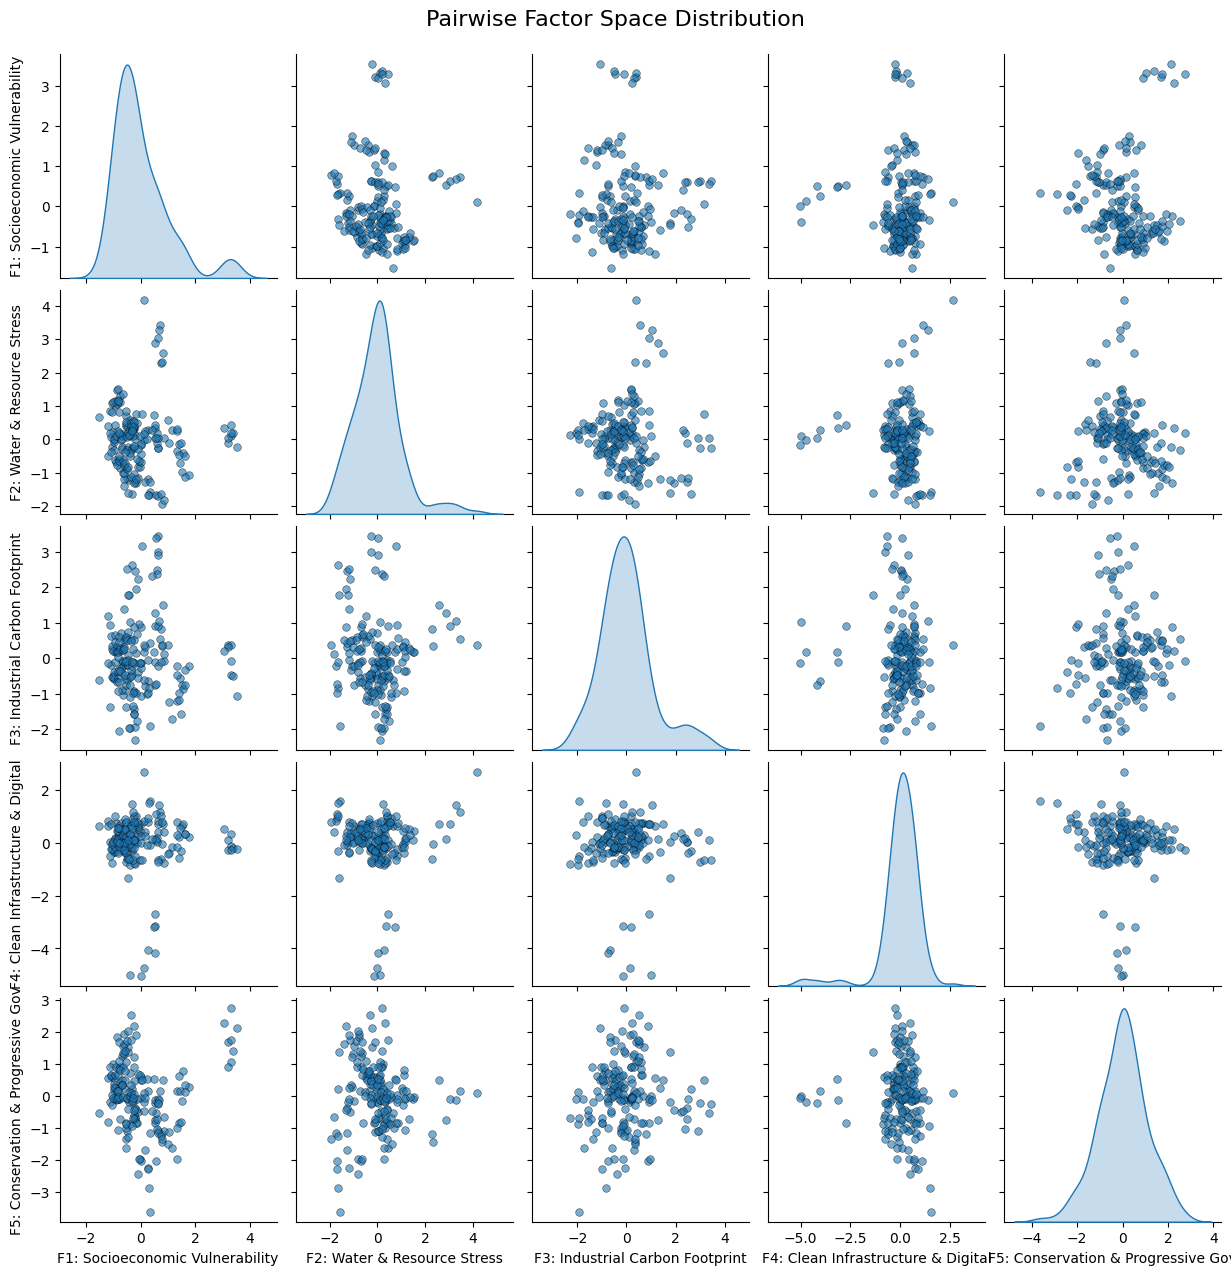

In [30]:
print("Generating Pairplot... This will show all 5 dimensions against each other.")

# Drop the text columns just for the pairplot matrix to avoid errors
pairplot_data = df_scores.drop(columns=['REF_AREA_LABEL', 'TIME_PERIOD'])

# Create the pairplot
sns.pairplot(
    pairplot_data,
    diag_kind='kde', # Shows the density/distribution of each factor on the diagonal
    plot_kws={'alpha': 0.6, 's': 30, 'edgecolor': 'k'},
    height=2.5
)
plt.suptitle('Pairwise Factor Space Distribution', y=1.02, fontsize=16)
plt.show()

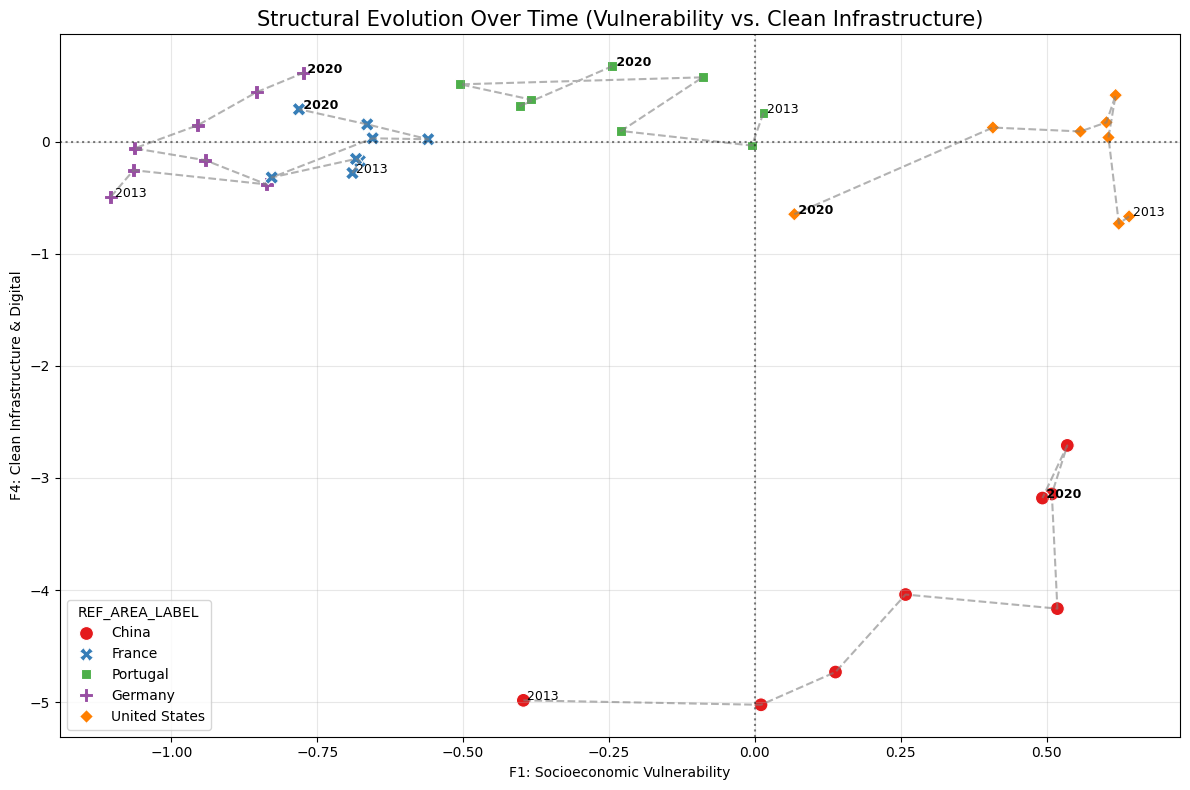

In [31]:
# Choose a few contrasting countries to look at
countries_to_track = ['Portugal', 'China', 'United States', 'France', 'Germany']

# Filter the scores for just these countries
df_track = df_scores[df_scores['REF_AREA_LABEL'].isin(countries_to_track)].sort_values(by='TIME_PERIOD')

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_track,
    x='F1: Socioeconomic Vulnerability',
    y='F4: Clean Infrastructure & Digital',
    hue='REF_AREA_LABEL',
    style='REF_AREA_LABEL',
    s=100,
    palette='Set1'
)

# Draw lines connecting the years for each country
for country in countries_to_track:
    country_data = df_track[df_track['REF_AREA_LABEL'] == country]
    plt.plot(
        country_data['F1: Socioeconomic Vulnerability'],
        country_data['F4: Clean Infrastructure & Digital'],
        color='gray',
        linestyle='--',
        alpha=0.6
    )

    # Optional: Label the starting and ending years
    if not country_data.empty:
        start_pt = country_data.iloc[0]
        end_pt = country_data.iloc[-1]
        plt.text(start_pt['F1: Socioeconomic Vulnerability'], start_pt['F4: Clean Infrastructure & Digital'], f" {int(start_pt['TIME_PERIOD'])}", fontsize=9)
        plt.text(end_pt['F1: Socioeconomic Vulnerability'], end_pt['F4: Clean Infrastructure & Digital'], f" {int(end_pt['TIME_PERIOD'])}", fontsize=9, fontweight='bold')

plt.title('Structural Evolution Over Time (Vulnerability vs. Clean Infrastructure)', fontsize=15)
plt.axhline(0, color='black', linestyle=':', alpha=0.5)
plt.axvline(0, color='black', linestyle=':', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

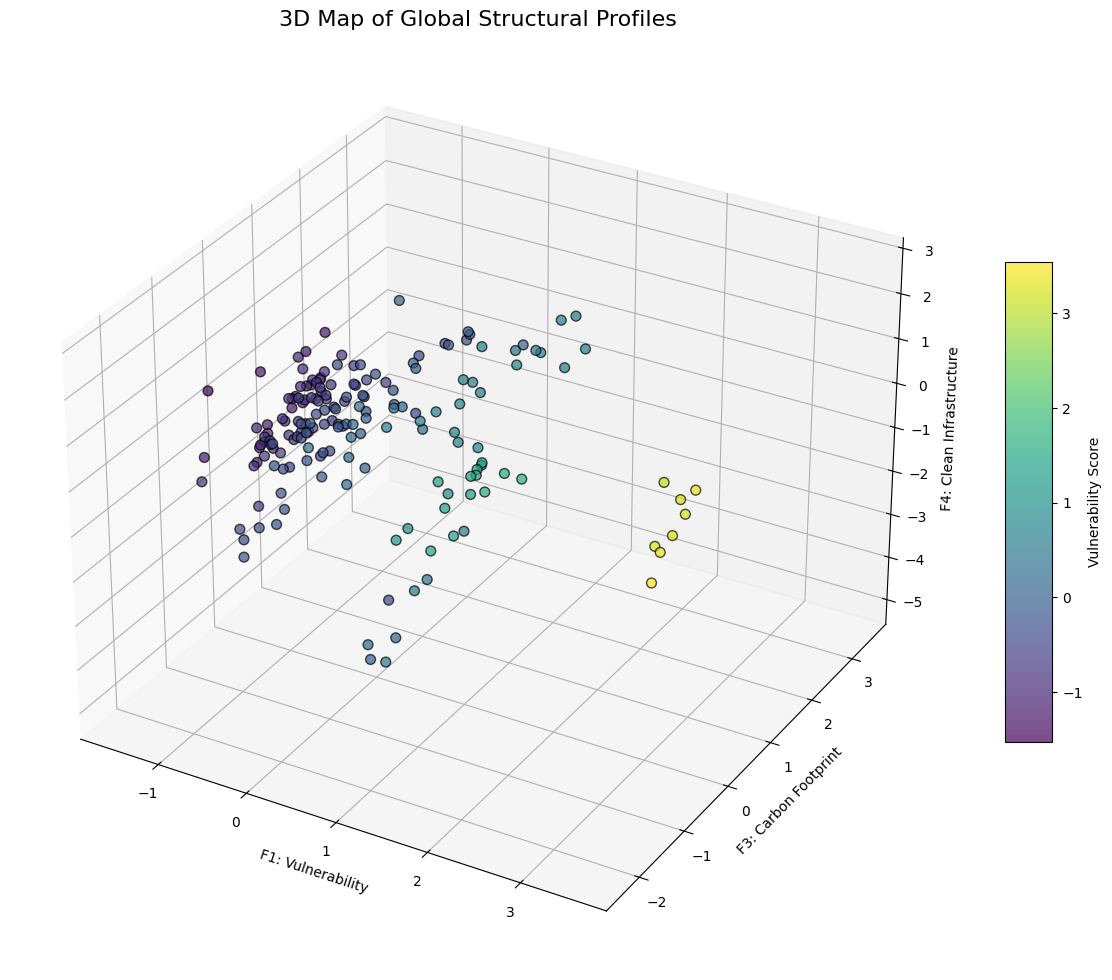

In [34]:
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Plotting F1, F3, and F4 to see Vulnerability, Carbon Footprint, and Clean Infrastructure
scatter = ax.scatter(
    df_scores['F1: Socioeconomic Vulnerability'],
    df_scores['F3: Industrial Carbon Footprint'],
    df_scores['F4: Clean Infrastructure & Digital'],
    c=df_scores['F1: Socioeconomic Vulnerability'], # Color by Vulnerability for visual depth
    cmap='viridis',
    s=50,
    alpha=0.7,
    edgecolor='k'
)

ax.set_title('3D Map of Global Structural Profiles', fontsize=16)
ax.set_xlabel('F1: Vulnerability')
ax.set_ylabel('F3: Carbon Footprint')
ax.set_zlabel('F4: Clean Infrastructure')

# Add a color bar
cbar = fig.colorbar(scatter, ax=ax, shrink=0.5, aspect=10)
cbar.set_label('Vulnerability Score')

plt.tight_layout()
plt.show()

## Task 4: Cluster Analysis

In [36]:
# --- 1. Isolate the Factor Scores for Clustering ---

cluster_data = df_scores[['F1: Socioeconomic Vulnerability',
                          'F2: Water & Resource Stress',
                          'F3: Industrial Carbon Footprint',
                          'F4: Clean Infrastructure & Digital',
                          'F5: Conservation & Progressive Gov']]

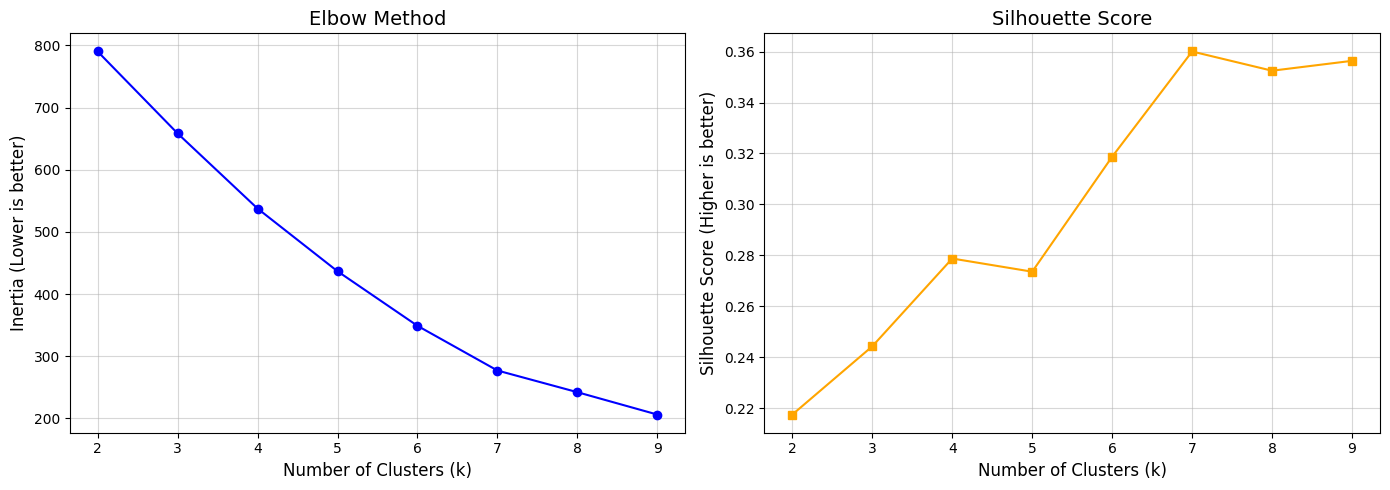

In [37]:
# --- 2. Determine an Appropriate Number of Clusters ---
inertia = []
sil_scores = []
k_values = range(2, 10) # Testing between 2 and 9 clusters

# Run K-Means for each 'k' to gather metrics
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_data)
    inertia.append(kmeans.inertia_)
    sil_scores.append(silhouette_score(cluster_data, kmeans.labels_))

# Plot the metrics to visually determine the best 'k'
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Elbow Plot (Look for the bend)
ax[0].plot(k_values, inertia, marker='o', color='blue')
ax[0].set_title('Elbow Method', fontsize=14)
ax[0].set_xlabel('Number of Clusters (k)', fontsize=12)
ax[0].set_ylabel('Inertia (Lower is better)', fontsize=12)
ax[0].grid(True, alpha=0.5)

# Silhouette Score Plot (Look for the peak)
ax[1].plot(k_values, sil_scores, marker='s', color='orange')
ax[1].set_title('Silhouette Score', fontsize=14)
ax[1].set_xlabel('Number of Clusters (k)', fontsize=12)
ax[1].set_ylabel('Silhouette Score (Higher is better)', fontsize=12)
ax[1].grid(True, alpha=0.5)

plt.tight_layout()
plt.show()

Two ways to go here

* **Silhouette Score:** Global max at 7 (mathematically solid but hard to interpret 7 groups), local max at 4 (not the global max but easier to interpret 4 profiles)
* **Elbow Method:** Kinda starts smoothing around 6 or 7

Will go with 7 first.



In [38]:
# --- 3. Assign Each Observation to a Cluster ---

optimal_k = 7
print(f"\nApplying K-Means clustering with k={optimal_k}...")

final_kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_scores['Cluster'] = final_kmeans.fit_predict(cluster_data)


Applying K-Means clustering with k=7...


In [39]:
# --- 4. Examine Cluster Characteristics ---
# Calculate the average factor scores for each cluster
cluster_means = df_scores.groupby('Cluster')[cluster_data.columns].mean()

print("\n--- Average Factor Scores by Cluster ---")
print(cluster_means.round(3))


--- Average Factor Scores by Cluster ---
         F1: Socioeconomic Vulnerability  F2: Water & Resource Stress  \
Cluster                                                                 
0                                  0.626                        3.005   
1                                  0.606                       -0.827   
2                                  2.406                       -0.291   
3                                 -0.627                       -0.810   
4                                  0.258                        0.226   
5                                 -0.578                        0.354   
6                                  0.123                       -0.549   

         F3: Industrial Carbon Footprint  F4: Clean Infrastructure & Digital  \
Cluster                                                                        
0                                  0.847                               0.760   
1                                 -0.316                    

### **Interpretation of Clusters**

**Cluster 0: The Water-Stressed Developers**

* **Key Traits:** Massive water & resource stress (F2 = 3.005), combined with moderately high carbon footprints and clean infrastructure.
* **Profile:** These are likely arid, rapidly developing, or resource-rich nations (like many Middle Eastern or North African states) that have built modern infrastructure but face severe geographic and hydrological constraints.

**Cluster 1: The Governance & Conservation Laggards**

* **Key Traits:** Extremely low conservation and progressive governance (F5 = -1.658).
* **Profile:** These countries struggle significantly with political inclusion (e.g., low women in parliament) and environmental conservation (e.g., high agricultural emissions, deforestation), alongside moderate socioeconomic vulnerability.

**Cluster 2: The Vulnerable "Green" States**

* **Key Traits:** Extremely high socioeconomic vulnerability (F1 = 2.406) but highly positive conservation/governance (F5 = 1.009) and low carbon footprints (F3 = -0.419).
* **Profile:** These are heavily impoverished or developing nations (often in the tropics or Sub-Saharan Africa). Their low carbon footprint and high "conservation" score are often a byproduct of a lack of heavy industry and high natural forest cover, rather than active green policies.

**Cluster 3: The Progressive Developed Nations**

* **Key Traits:** Very low vulnerability (F1 = -0.627), very low water stress (F2 = -0.810), and extremely high progressive governance (F5 = 1.414).
* **Profile:** These are the wealthiest, most stable nations in the world (likely Nordic and Western European countries). They boast high equality, excellent infrastructure, strong political inclusion, and active conservation efforts.

**Cluster 4: The Infrastructure-Deficient**

* **Key Traits:** An absolute collapse in clean infrastructure and digital connectivity (F4 = -3.997).
* **Profile:** This cluster isolates countries experiencing severe structural deficits in basic modern necessities (like internet access, electricity, and clean cooking fuels).

**Cluster 5: The Stable Low-Emitters**

* **Key Traits:** Low vulnerability (F1 = -0.578) and low industrial carbon footprints (F3 = -0.512).
* **Profile:** These are developed, stable nations whose economies likely lean heavily toward services rather than heavy manufacturing, resulting in a much lower environmental toll.

**Cluster 6: The Heavy Industrializers**

* **Key Traits:** An extraordinarily high industrial carbon footprint (F3 = 2.526).
* **Profile:** These are the global manufacturing powerhouses (likely capturing countries like China, the US, or India). Their massive economies are driven by heavy industry, resulting in world-leading emissions and habitat loss.

## Task 5: Cluster Visualization

/tmp/ipykernel_599/2005768367.py:23: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  plt.text(row[0], row[1], f' C{cluster_id} ',


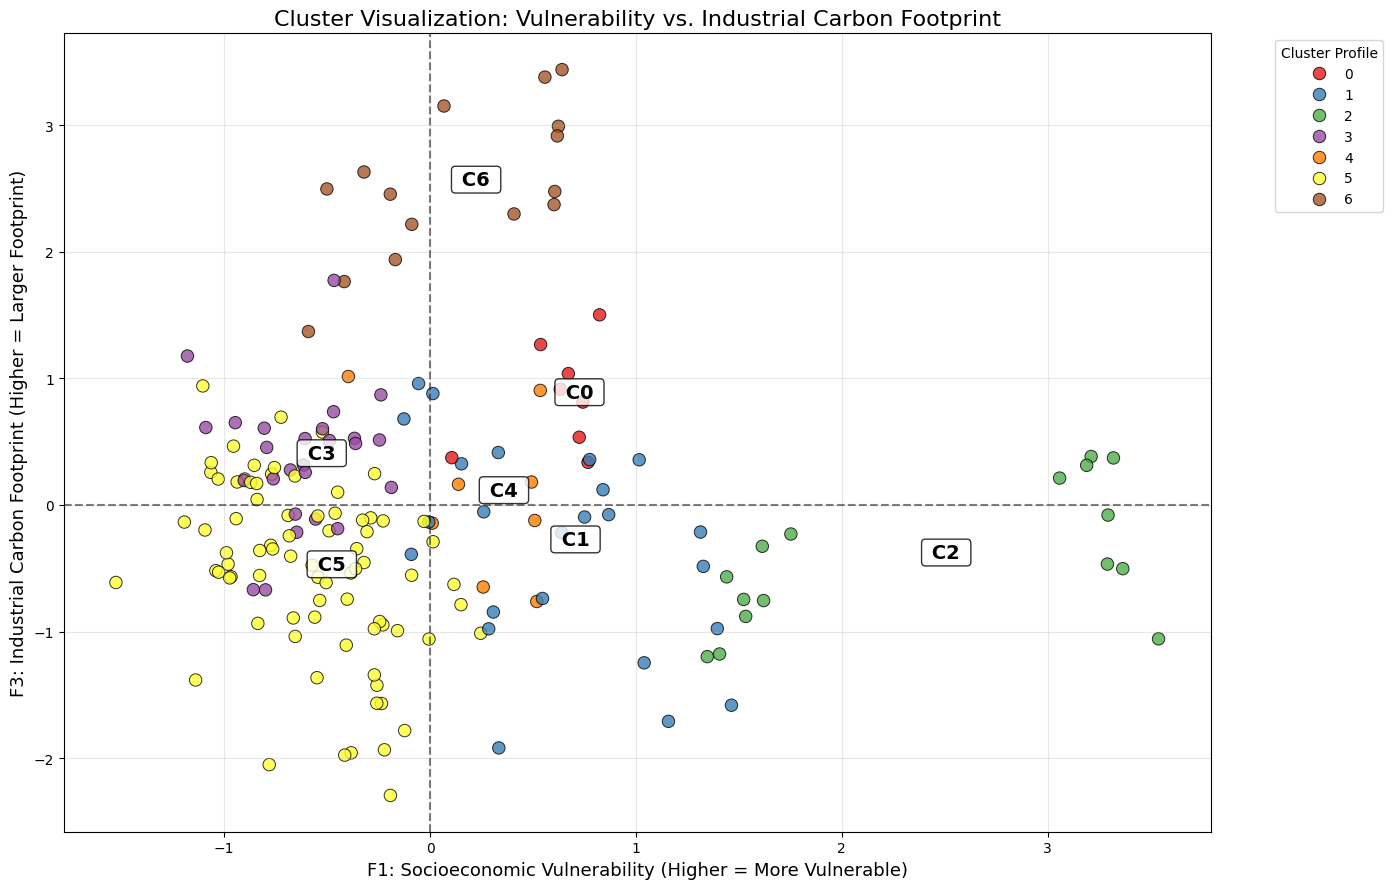

In [40]:
# 1. Plot observations using the factor scores
plt.figure(figsize=(14, 9))

# F1 (Vulnerability) vs F3 (Carbon Footprint) as it creates great separation
sns.scatterplot(
    data=df_scores,
    x='F1: Socioeconomic Vulnerability',
    y='F3: Industrial Carbon Footprint',
    hue='Cluster',
    palette='Set1',   # Distinct colors for our 7 clusters
    alpha=0.8,
    s=80,
    edgecolor='k'
)

# Add quadrant lines at 0 (the standardized average)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.axvline(0, color='black', linestyle='--', alpha=0.5)

# Annotate the cluster centers to see exactly where the "average" of each group sits
cluster_centers = df_scores.groupby('Cluster')[['F1: Socioeconomic Vulnerability', 'F3: Industrial Carbon Footprint']].mean()
for cluster_id, row in cluster_centers.iterrows():
    plt.text(row[0], row[1], f' C{cluster_id} ',
             fontsize=14, weight='bold', color='black',
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='black', boxstyle='round,pad=0.2'))

plt.title('Cluster Visualization: Vulnerability vs. Industrial Carbon Footprint', fontsize=16)
plt.xlabel('F1: Socioeconomic Vulnerability (Higher = More Vulnerable)', fontsize=13)
plt.ylabel('F3: Industrial Carbon Footprint (Higher = Larger Footprint)', fontsize=13)
plt.legend(title='Cluster Profile', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()

* **Clear Separation of Extremes:** The extremes of the global spectrum are incredibly well separated. C2 (The Vulnerable "Green" States) are isolated far on the right—they share the similarity of extreme socioeconomic vulnerability but consistently low industrial footprints. Conversely, C6 (The Heavy Industrializers) are clustered tightly near the top left, sharing massive carbon footprints but relatively low vulnerability.
* **The Development/Emissions Trade-off:** The plot reveals a clear inverse relationship. Countries facing the highest vulnerability rarely have heavy industrial emissions, while the heaviest emitters have largely solved their baseline socioeconomic vulnerabilities.

Same iteration coule be visualized for all variable pairs.

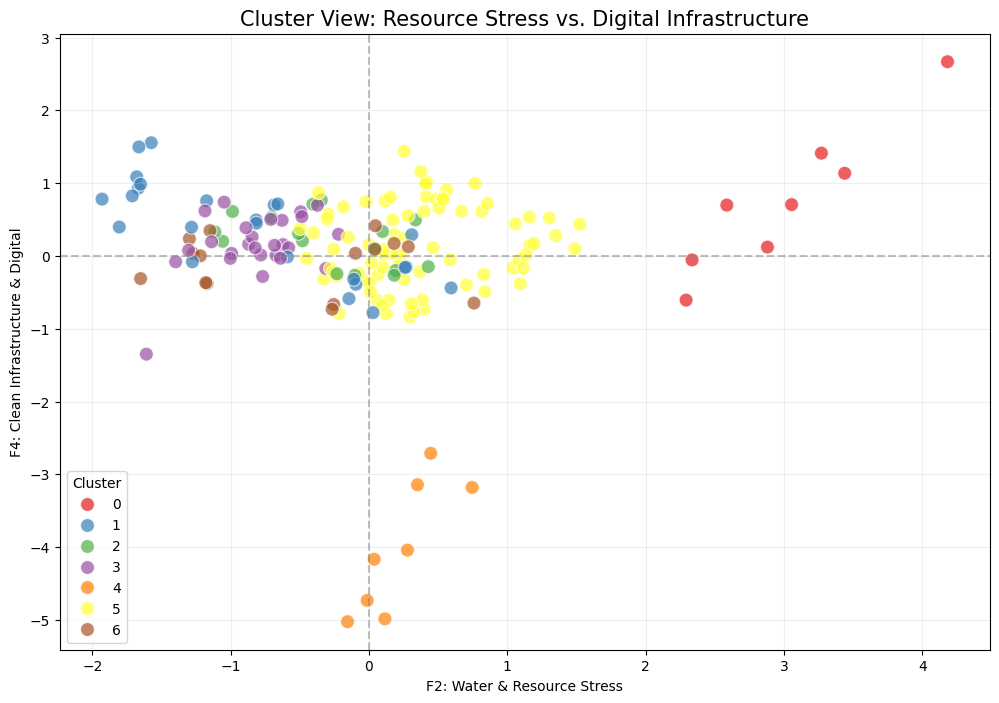

In [49]:
# Another example
plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=df_scores,
    x='F2: Water & Resource Stress',
    y='F4: Clean Infrastructure & Digital',
    hue='Cluster',
    palette='Set1',
    s=100,
    alpha=0.7,
    edgecolor='w'
)
plt.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.axvline(0, color='gray', linestyle='--', alpha=0.5)
plt.title('Cluster View: Resource Stress vs. Digital Infrastructure', fontsize=15)
plt.grid(True, alpha=0.2)
plt.show()

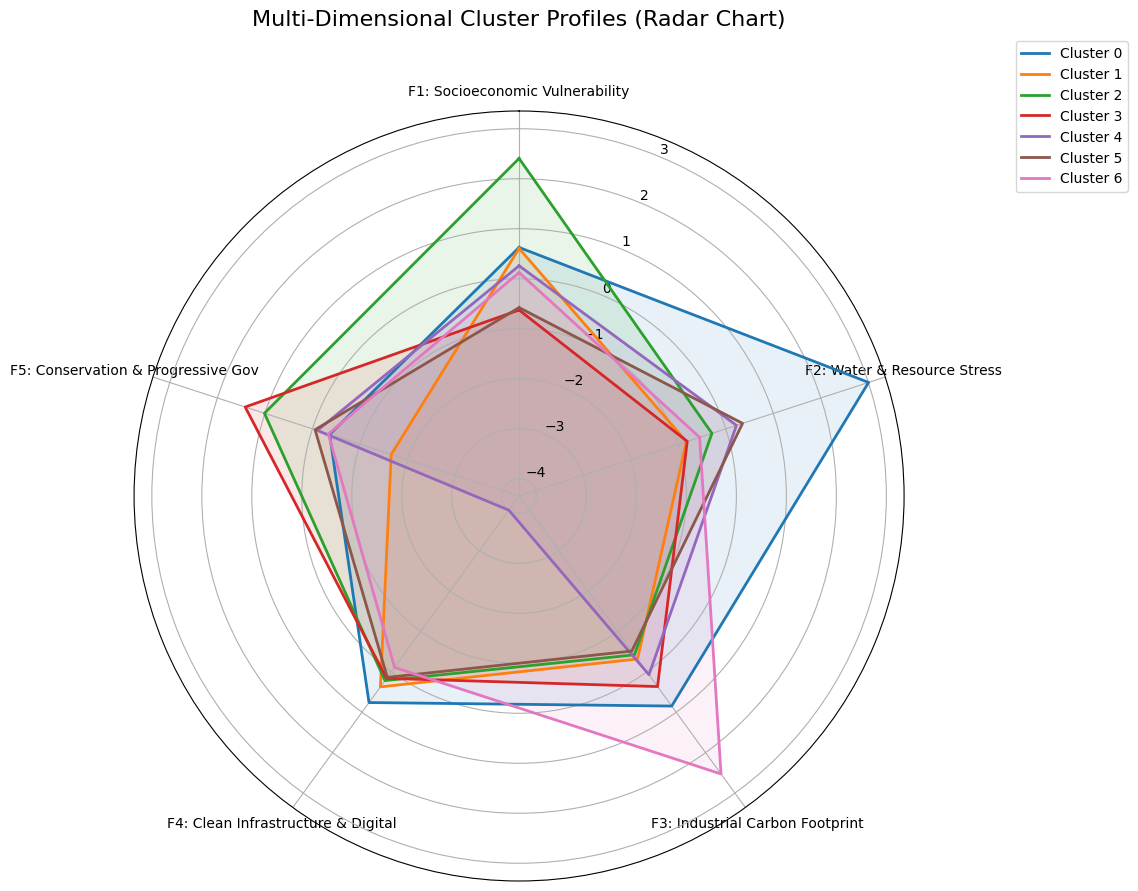

In [45]:
# 1. Prepare data for Radar Chart
labels = cluster_data.columns
num_vars = len(labels)

# Compute angles for each axis
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # Close the loop

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw=dict(polar=True))

# Plot each cluster
for i in range(optimal_k):
    values = cluster_means.iloc[i].tolist()
    values += values[:1]  # Close the loop
    ax.plot(angles, values, linewidth=2, label=f'Cluster {i}')
    ax.fill(angles, values, alpha=0.1)

# Fix axis labels
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)

plt.title('Multi-Dimensional Cluster Profiles (Radar Chart)', size=16, y=1.1)
plt.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

**Cluster 4** is unique solely because of its extreme infrastructure deficit, while **Cluster 0** is unique because of its water stress.

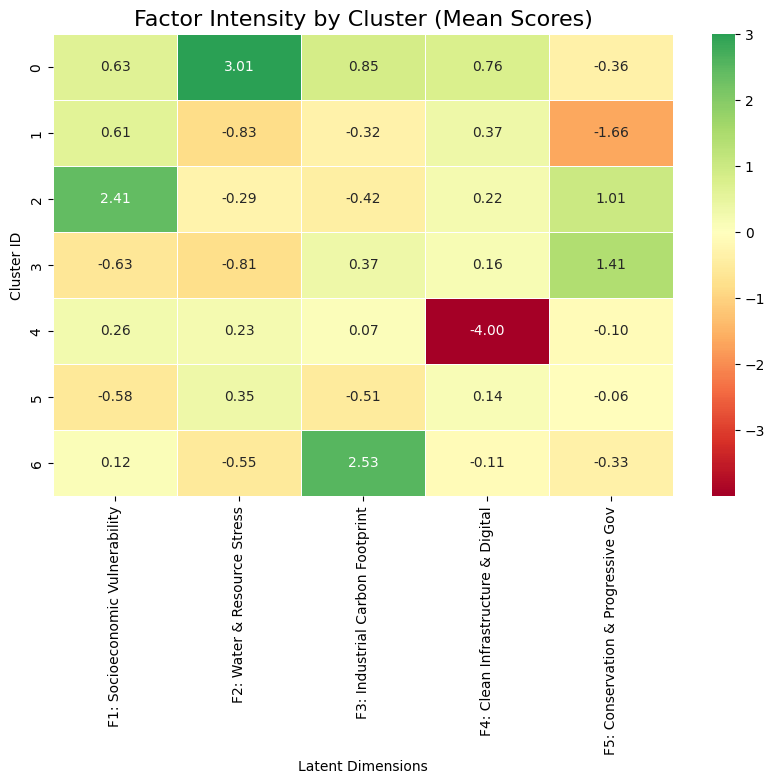

In [46]:
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_means, annot=True, cmap='RdYlGn', center=0, fmt=".2f", linewidths=.5)
plt.title('Factor Intensity by Cluster (Mean Scores)', fontsize=16)
plt.ylabel('Cluster ID')
plt.xlabel('Latent Dimensions')
plt.show()

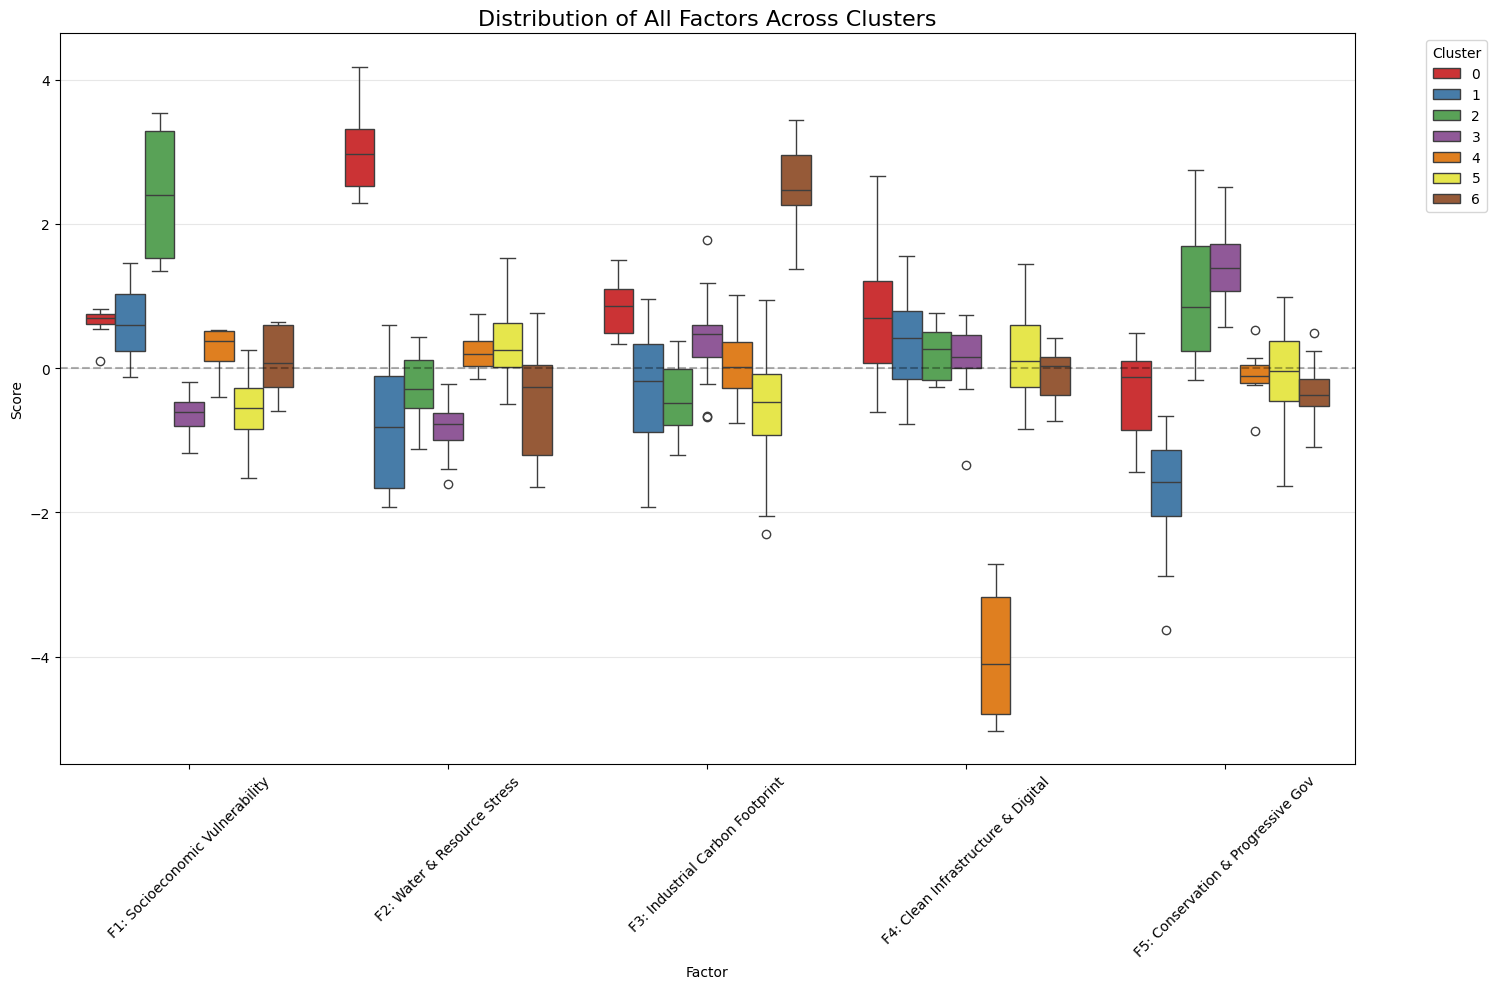

In [47]:
# Melt the data for easier plotting with Seaborn
df_melted = df_scores.melt(id_vars=['Cluster'], value_vars=cluster_data.columns,
                           var_name='Factor', value_name='Score')

plt.figure(figsize=(15, 10))
sns.boxplot(data=df_melted, x='Factor', y='Score', hue='Cluster', palette='Set1')
plt.title('Distribution of All Factors Across Clusters', fontsize=16)
plt.xticks(rotation=45)
plt.axhline(0, color='black', linestyle='--', alpha=0.3)
plt.grid(axis='y', alpha=0.3)
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

Shows statistical proof.
Takes **Factor 1** for example, can clearly see **Cluster 2** being statistically distinct from the other clusters.

## Task 6: Cluster Evolution Over Time

In [43]:
# --- Copy the cluster labels from df_scores over to df_final ---
df_final['Cluster'] = df_scores['Cluster'].values

# 1. Track the cluster assignment of each country across years
# We pivot the table so countries are rows, years are columns, and cell values are the assigned clusters
cluster_evolution = df_final.pivot(index='REF_AREA_LABEL', columns='TIME_PERIOD', values='Cluster')

# Calculate how many different clusters each country has belonged to across the years
cluster_evolution['Num_Unique_Clusters'] = cluster_evolution.nunique(axis=1)

# 2. Identify countries that remain in the same cluster
stable_countries = cluster_evolution[cluster_evolution['Num_Unique_Clusters'] == 1]

# 3. Identify countries that move between clusters
transition_countries = cluster_evolution[cluster_evolution['Num_Unique_Clusters'] > 1]

# Display the summary
print(f"--- Cluster Evolution Summary ---")
print(f"Countries that remained in the SAME cluster: {len(stable_countries)}")
print(f"Countries that MOVED between clusters: {len(transition_countries)}")

# Show the exact transition paths for the countries that moved
if not transition_countries.empty:
    print("\n--- Transition Paths for Moving Countries ---")
    # We drop the 'Num_Unique_Clusters' column just for a cleaner printout
    paths = transition_countries.drop(columns=['Num_Unique_Clusters'])
    print(paths.head(15)) # Showing the first 15 for review

--- Cluster Evolution Summary ---
Countries that remained in the SAME cluster: 19
Countries that MOVED between clusters: 3

--- Transition Paths for Moving Countries ---
TIME_PERIOD     2013  2014  2015  2016  2017  2018  2019  2020
REF_AREA_LABEL                                                
Canada             6     6     6     6     6     6     6     3
Denmark            5     5     5     5     5     5     3     3
Sweden             3     3     3     3     3     5     3     3


## Task 7: Development Paths

**Canada (C6 to C3 in 2020)**

Canada spent 2013-2019 in Cluster 6 (The Heavy Industrializers), marked by massive industrial carbon footprints. In 2020, it transitioned to Cluster 3 (The Progressive Developed Nations). This is a massive structural upgrade. This shift likely corresponds to the dramatic drop in industrial emissions and energy intensity during the 2020 global pandemic, combined with strong progressive governance scores.

**Denmark (C5 to C3 in 2019)**

Denmark moved from Cluster 5 (The Stable Low-Emitters) to Cluster 3 (The Progressive Developed Nations). This is a clear development trajectory. Denmark was already doing well, but in 2019, it mathematically crossed the threshold into the absolute highest tier of progressive governance and environmental conservation.

**Sweden (C3 to C5 to C3)**

Sweden shows a temporary dip. It dropped out of the top-tier Cluster 3 down to Cluster 5 in 2018, before immediately recovering in 2019. This suggests a temporary anomaly in their data for that specific year rather than a permanent structural decline.

Data shows that structural clusters are overwhelmingly stable. The 19 countries that did not move prove that fundamental macroeconomic DNA rarely shifts over a short 7-year period.

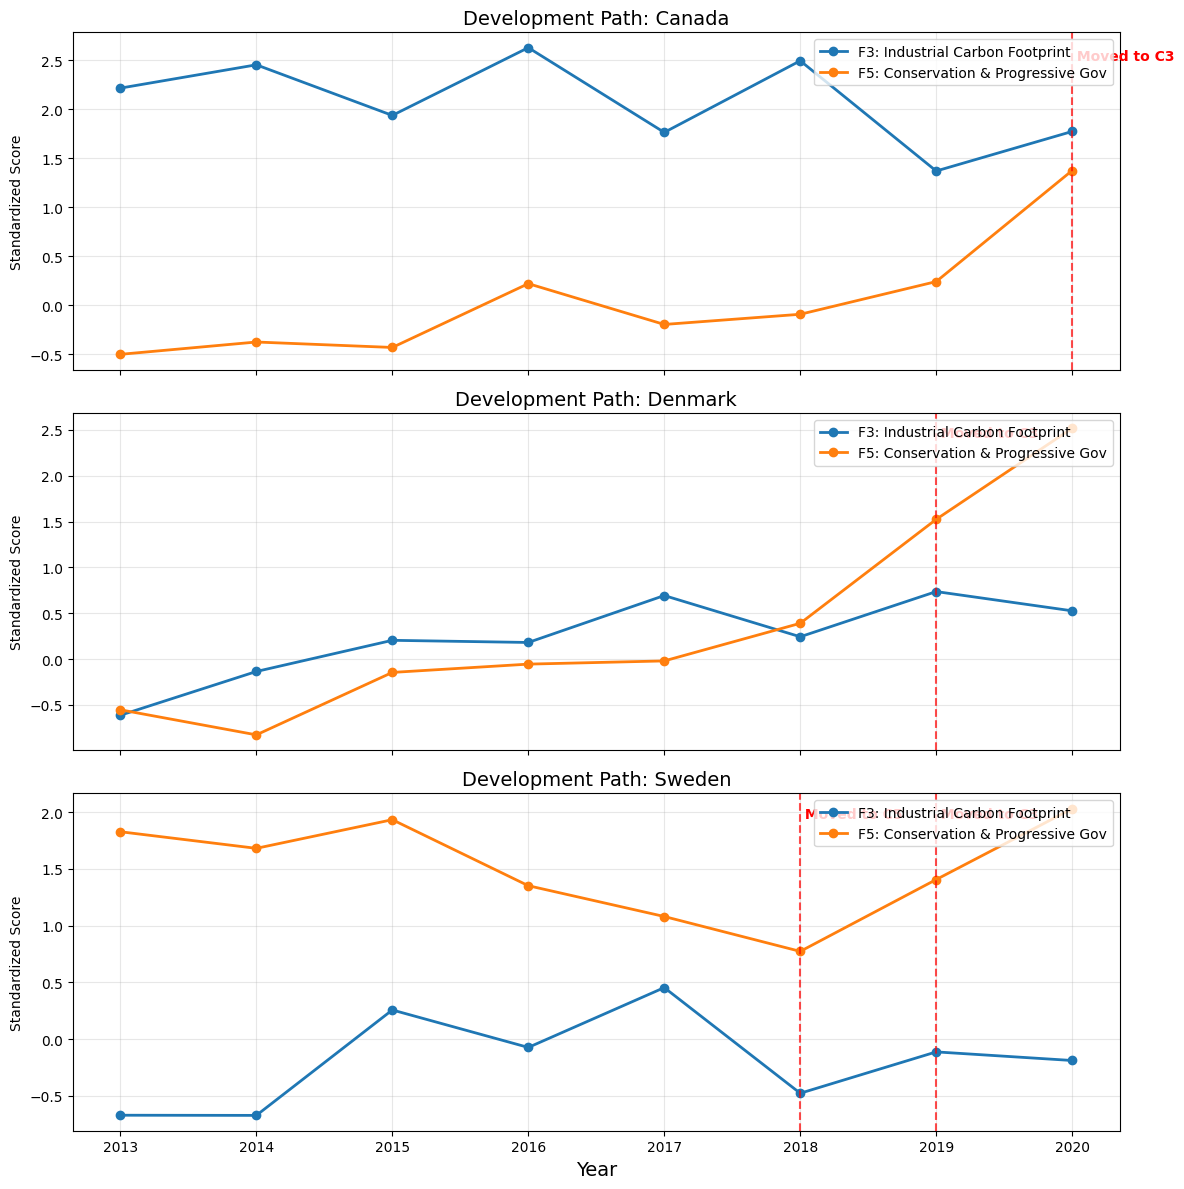

In [44]:
# Isolate the moving countries
moving_countries = ['Canada', 'Denmark', 'Sweden']
df_moving = df_scores[df_scores['REF_AREA_LABEL'].isin(moving_countries)].sort_values(by=['REF_AREA_LABEL', 'TIME_PERIOD'])

# Create a plot showing how their specific Factor scores changed over time
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)
factors_to_plot = ['F3: Industrial Carbon Footprint', 'F5: Conservation & Progressive Gov']

for idx, country in enumerate(moving_countries):
    country_data = df_moving[df_moving['REF_AREA_LABEL'] == country]

    # Plot the factor scores over time
    for factor in factors_to_plot:
        axes[idx].plot(country_data['TIME_PERIOD'], country_data[factor], marker='o', label=factor, linewidth=2)

    # Add a background color change to show when the cluster transitioned
    for i in range(len(country_data) - 1):
        year1 = country_data['TIME_PERIOD'].iloc[i]
        year2 = country_data['TIME_PERIOD'].iloc[i+1]
        cluster1 = country_data['Cluster'].iloc[i]
        cluster2 = country_data['Cluster'].iloc[i+1]

        if cluster1 != cluster2:
            axes[idx].axvline(x=year2, color='red', linestyle='--', alpha=0.7)
            axes[idx].text(year2, axes[idx].get_ylim()[1]*0.9, f' Moved to C{cluster2}', color='red', fontweight='bold')

    axes[idx].set_title(f'Development Path: {country}', fontsize=14)
    axes[idx].set_ylabel('Standardized Score')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(loc='upper right')

plt.xlabel('Year', fontsize=14)
plt.tight_layout()
plt.show()

**Canada**

Its transition to C3 (Progressive Developed Nations) in 2020 was directly driven by a massive spike in its Conservation & Progressive Governance score (F5), combined with a significant drop in its Industrial Carbon Footprint (F3) from its 2017 peak.

**Denmark**

This is a textbook development trajectory. Denmark didn't just stumble into C3; it experienced a relentless, multi-year surge in its F5 score, finally crossing the mathematical threshold in 2019.

**Sweden**

The chart explains the temporary cluster dip. Sweden's F5 score plummeted between 2015 and 2018, dropping it out of C3. But in 2019, it aggressively reversed that trend, snapping right back into its original cluster.

## Discussion Questions

**What are the main latent dimensions identified by factor analysis?**

We identified 5 main dimensions: Socioeconomic Vulnerability (driven by inequality and undernourishment), Water & Resource Stress (driven by freshwater withdrawals), Industrial Carbon Footprint (driven by CO2 and tree cover loss), Clean Infrastructure & Digital (driven by clean fuels and internet access), and Conservation & Progressive Governance (driven by women in parliament and low agricultural emissions).

**How many clusters best represent the data?**

Based on the Silhouette Score peak and the Elbow Method curve, 7 clusters provided the most mathematically optimal and well-separated representation of the data.

**What are the key characteristics of each cluster?**

* C0 (Water-Stressed): High geographic/hydrological constraints.
* C1 (Laggards): Poor governance and low conservation.
* C2 (Vulnerable "Green"): High poverty/vulnerability but low industrial emissions.
* C3 (Progressive Developed): Wealthy, stable, highly inclusive, and green.
* C4 (Infrastructure-Deficient): Lacking basic modern infrastructure (internet, clean cooking).
* C5 (Stable Low-Emitters): Developed service economies with low carbon footprints.
* C6 (Heavy Industrializers): Massive carbon and environmental footprints.

**Which variables contribute most to the separation between clusters?**

The variables with the highest factor loadings drive the separation. Key dividers include the Gini index (inequality), CO2 emissions per capita, Annual freshwater withdrawals, Access to clean fuels, and the Proportion of seats held by women in national parliaments.

**Do countries tend to remain in the same cluster over time?**

Yes, structural profiles are highly stable. In our sample, the vast majority of countries (19) remained in the exact same cluster across the entire 7-year period, proving that macroeconomic and structural changes happen slowly over time.

**Can you identify examples of countries moving between clusters?**

Yes, Canada, Denmark, and Sweden all exhibited movement between clusters during the observed timeframe.

**What factors might explain these transitions?**

Transitions are explained by significant, sustained shifts in specific latent dimensions. For example, Denmark's transition was fueled by a multi-year improvement in progressive governance and conservation policies. Sudden drops and recoveries (like Sweden) might be explained by short-term political shifts or temporary shocks to agricultural/industrial outputs.